In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
torch.manual_seed(42)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device is {device}")

Device is cuda


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/sample data/fashion-mnist_train.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(60000, 785)

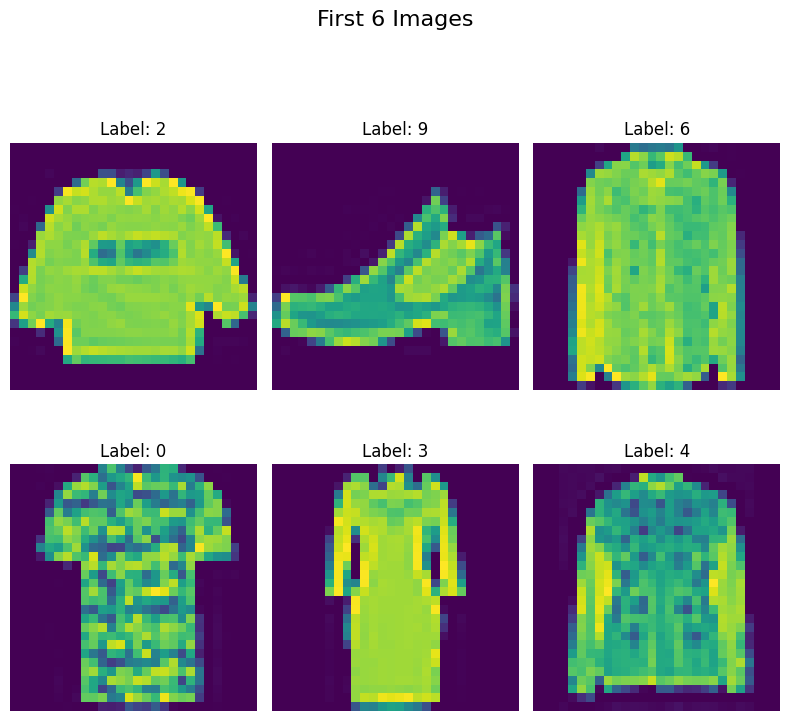

In [ ]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(2, 3, figsize=(8, 8))
fig. suptitle("First 6 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28) # Reshape to 28x28
    ax.imshow(img) # Display in grayscale
    ax.axis('off') # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}") # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to fit the title
plt.show()

In [ ]:
X = df.drop("label", axis = 1).to_numpy()
y = df["label"].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

X_train = X_train/255
X_test = X_test/255

In [ ]:
class customdata(Dataset):
    def __init__(self, features, labels):

        self.features = torch.tensor(features, dtype= torch.float32)
        self.labels = torch.tensor(labels, dtype= torch.long)

    def __len__(self):
        return self.features.shape[0]
    def __getitem__(self, index):
        return self.features[index], self.labels[index]


In [ ]:
train_dataset = customdata(X_train, y_train)

test_dataset = customdata(X_test, y_test)

#### Model

In [ ]:
class MyNN(nn.Module):
    def __init__(self, input_dim, output_dim, num_hidden_layers, nuron_per_layer, drop_out_rate):

        super().__init__()

        layer = []

        for num_hidden_layer in range(num_hidden_layers):
            layer.append(nn.Linear(input_dim, nuron_per_layer))
            layer.append(nn.BatchNorm1d(nuron_per_layer))
            layer.append(nn.ReLU())
            layer.append(nn.Dropout(drop_out_rate))
            input_dim = nuron_per_layer
        layer.append(nn.Linear(input_dim, output_dim))

        self.model = nn.Sequential(*layer)    # * ----> for unpacking List

    def forward(self, x):
        return self.model(x)

##### Objective Functions

In [ ]:
def objective(trial):

    # next layer Hyperparameters
    num_hidden_layers = trial.suggest_int("num_hidden_layers", 1,5)
    nuron_per_layer = trial.suggest_int("nuron_per_layer", 8, 128, step = 8)
    drop_out_rate = trial.suggest_float("drop_out_rate", 0.1,0.5, step = .1)
    lr = trial.suggest_float("Learning_Rate", 1e-5, 1e-1, log = True)
    epochs = trial.suggest_int("Epoches", 10,50, step = 10)
    batch_size = trial.suggest_catagorical("Batch_Size", [16, 32, 64, 128])
    optimizer_name = trial.suggest_catagorical("Optimizer_Name", ["Adam", "SGD", "RMSprop"])
    weight_decay = trial.suggest_float("Weight_decay", 1e-5, 1e-3, log = True)



    # model initial
    input_dim = X_train.shape[1]
    output_dim = len(np.unique(y_train))

    model = MyNN(input_dim, output_dim, num_hidden_layers, nuron_per_layer, drop_out_rate)
    model.to(device)

    # Paramms
    #lr = 0.01
    #epochs = 5
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory= True)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, pin_memory= True)

    # Optimizer selection
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr = lr, weight_decay= weight_decay)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr = lr, weight_decay= weight_decay)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr = lr, weight_decay= weight_decay)


    # training Loop
    for epoch in range (epochs):


        for batch_features, batch_labels in train_dataloader:

            #Moving Features and labes to GPU
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    
            # forward pass
            output = model(batch_features)

            # losss calculation
            loss = criterion(output, batch_labels)

            # gradient to 0
            optimizer.zero_grad()

            # Back Pass
            loss.backward()


            #updating grads
            optimizer.step()

    # Evalution
    model.eval()

    total = 0
    correct = 0

    with torch.no_grad():
        for batch_features, batch_labels in test_dataloader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)


            output = model(batch_features)

            val, predicted_index = torch.max(output, 1)    # dim 1 wise searching|

            total += batch_labels.shape[0]

            correct = correct+(predicted_index == batch_labels).sum().item()

            accurecy = correct/total
        return (accurecy)


In [ ]:
! pip install optuna


In [ ]:
import optuna

In [ ]:
study = optuna.create_study(direction= "maximize")

[I 2026-08-06 21:48:31,510] A new study created in memory with name: no-name-506f01b0-b462-42dc-aec8-f0ee1c21e9ab


In [ ]:
study.optimize(objective, n_trials=10)

[I 2026-08-06 21:49:07,149] Trial 0 finished with value: 0.8548333333333333 and parameters: {'num_hidden_layers': 3, 'nuron_per_layer': 72}. Best is trial 0 with value: 0.8548333333333333.
[I 2026-08-06 21:49:31,895] Trial 1 finished with value: 0.8625833333333334 and parameters: {'num_hidden_layers': 2, 'nuron_per_layer': 112}. Best is trial 1 with value: 0.8625833333333334.
[I 2026-08-06 21:49:57,938] Trial 2 finished with value: 0.8395833333333333 and parameters: {'num_hidden_layers': 2, 'nuron_per_layer': 24}. Best is trial 1 with value: 0.8625833333333334.
[I 2026-08-06 21:50:35,934] Trial 3 finished with value: 0.86 and parameters: {'num_hidden_layers': 4, 'nuron_per_layer': 88}. Best is trial 1 with value: 0.8625833333333334.
[I 2026-08-06 21:51:19,506] Trial 4 finished with value: 0.8546666666666667 and parameters: {'num_hidden_layers': 5, 'nuron_per_layer': 112}. Best is trial 1 with value: 0.8625833333333334.
[I 2026-08-06 21:51:38,989] Trial 5 finished with value: 0.86741666

In [ ]:
study.best_value

0.8676666666666667

In [ ]:
study.best_params

{'num_hidden_layers': 1, 'nuron_per_layer': 120}